# Multi-Layer Perceptron Neural Network (Pytorch)

## 0. Installation & Imports 

### Torch Installation (MPS)

In [1]:
import torch

if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    x = torch.ones(1, device=mps_device)
    print(x)
else:
    print("MPS device not found.")

tensor([1.], device='mps:0')


### Import Libraries 

In [2]:
# Data Analysis Libraries
import pandas as pd
import numpy as np
from IPython.display import HTML, display
from pprint import pprint

# Data Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams["figure.figsize"] = (14, 7)

# Machine Learning Libraries
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from tqdm import tqdm  # progress bar

# Data Preparation and Evaluation Libraries
import src.data_preprocess as dp
import src.evaluation as ev

print(f"Current pandas version: {pd.__version__}")

Current pandas version: 2.0.3


### Device Agnostic Code

In [3]:
device = "mps" if torch.mps.is_available() else "cpu"
print(f"✅ Using device: {device}")

✅ Using device: mps


## 1. Read Data

In [4]:
df1 = pd.read_csv("data/processed/creditcard_cleaned.csv")
df1.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
# some stats about the data
print(f"Number of Data Points: {df1.size}")
print(f"Number of Fradulent Transactions: {df1['Class'].value_counts()[1]}")
print(f"Number of Non-Fradulent Transactions: {df1['Class'].value_counts()[0]}\n")

Number of Data Points: 8795506
Number of Fradulent Transactions: 473
Number of Non-Fradulent Transactions: 283253



## 2. Stratified Splitting 

In [6]:
X = df1.drop(columns=["Class"])
y = df1["Class"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
# - Check Class Distribution -
print(y_train.value_counts())
print("==========================")
print(y_test.value_counts())

Class
0    226602
1       378
Name: count, dtype: int64
Class
0    56651
1       95
Name: count, dtype: int64


## 3. Feature Scaling 

In [8]:
# - Scaling of Train, Validation, Test Data  -
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()  # set_output(transform="pandas") shouldn't work here (Conversion to Tensor won't work)

# - Train StandardScaler() based on features in Train Data -
X_train_scaled = scaler.fit_transform(X_train)

# - Apply Learning to Test Data -
X_test_scaled = scaler.transform(X_test)

In [9]:
# - Check Scaling Validity Manually -
dp.check_scaling_validity(X_train_scaled)
dp.check_scaling_validity(X_test_scaled)

Feature means after scaling:
 0.04211337257935192

Feature std devs after scaling:
 1.4115090716241605
Feature means after scaling:
 0.04118829144075911

Feature std devs after scaling:
 1.4687385481030577


## 4. Data Preparation 

We will now be converting our training / testing inputs and labels to tensors, which allows Pytorch objects such as `Dataset` and `DataLoader` to interpret them, and distribute them to our neural network in the correct data type.

In [10]:
from torch.utils.data import TensorDataset

X_train_ts = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_ts = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_ts = torch.tensor(y_train.values, dtype=torch.int64)
y_test_ts = torch.tensor(y_test.values, dtype=torch.int64)
train_data = TensorDataset(
    X_train_ts, y_train_ts
)  # auto pairs 1st value of X_train with y_train

# For Features (X): Use FloatTensor (or torch.float32)
# For Classification Labels (y): Use LongTensor (or torch.int64)
# For Regression Targets (y): Use FloatTensor (or torch.float32)

In [11]:
print("Train Data")
print("=" * 25)
print(f"Features dtype: {X_train_ts.dtype}")
print(f"Labels dtype: {y_train_ts.dtype}")

# 5. Check shapes
print(f"X_train Tensor Shape: {X_train_ts.shape}")
print(f"y_train Tensor Shape: {y_train_ts.shape}\n")

print("Test Data")
print("=" * 25)
print(f"Features dtype: {X_test_ts.dtype}")
print(f"Labels dtype: {y_test_ts.dtype}")
print(f"X_test Tensor Shape: {X_test_ts.shape}")
print(f"y_test Tensor Shape: {y_test_ts.shape}")

Train Data
Features dtype: torch.float32
Labels dtype: torch.int64
X_train Tensor Shape: torch.Size([226980, 30])
y_train Tensor Shape: torch.Size([226980])

Test Data
Features dtype: torch.float32
Labels dtype: torch.int64
X_test Tensor Shape: torch.Size([56746, 30])
y_test Tensor Shape: torch.Size([56746])


## 5. Baseline MLP Neural Network Definition
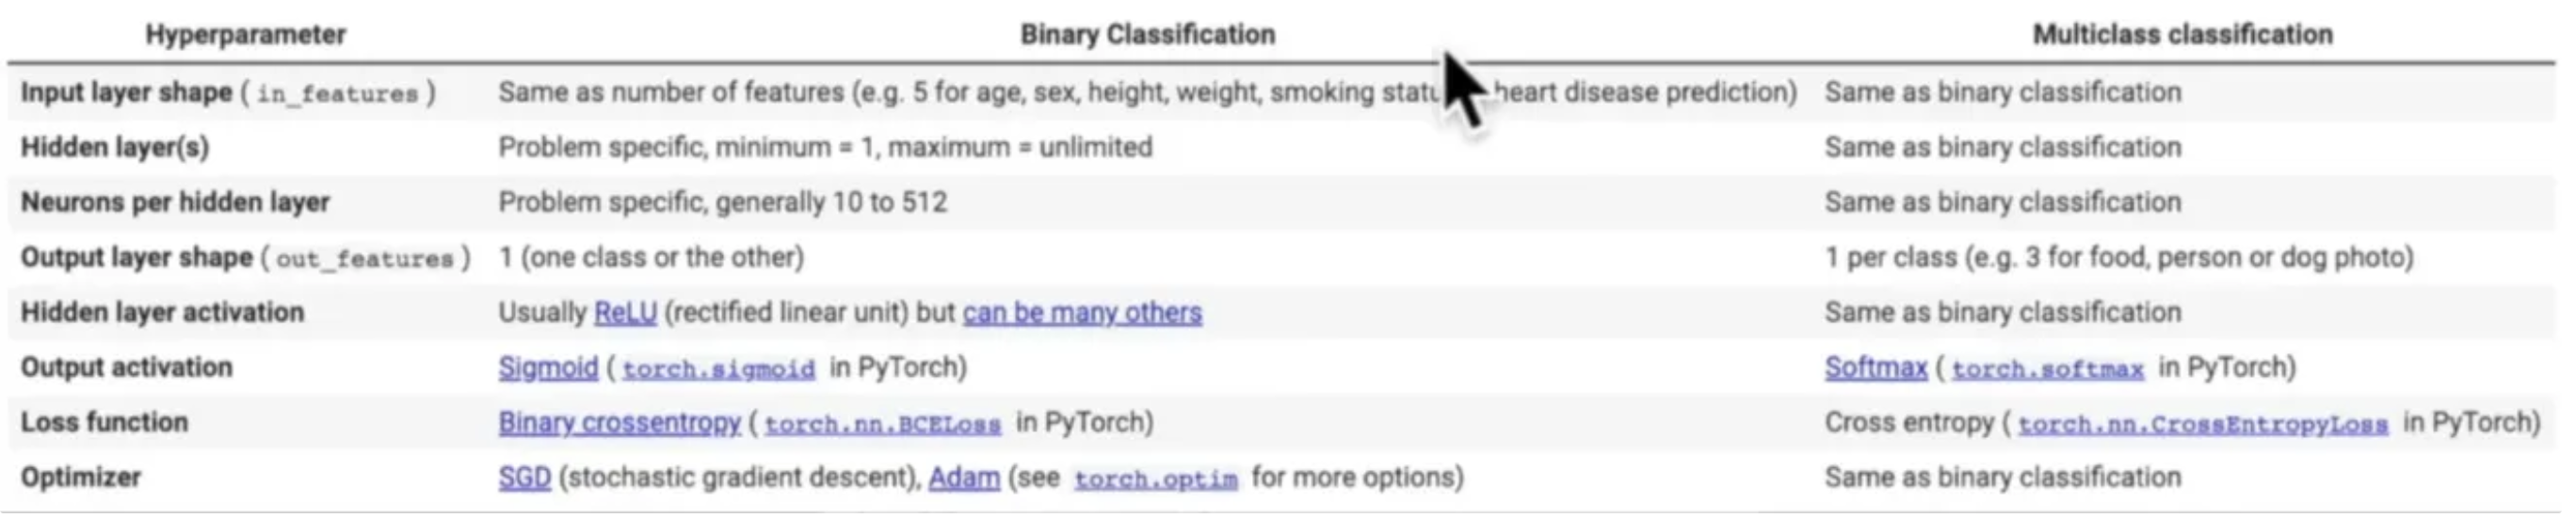

From the Daniel Bourke Pytorch Course, I obtained this guideline for binary vs multiclass classification. This framework shall be referenced to in the following steps. Also, since neural networks learn from complex patterns, there is no need for oversampling / other sampling techniques to address class imbalance. Also, we will be using `BCEWithLogitsLoss` with class weighting for the loss function, since it is numerically more stable and the class weighting approach helps address class imbalance issues. Additionally, our neural network doesn't have a sigmoid application to the output and it outputs raw logits / scores. 

### Compute Class Weights 

In [12]:
# Dealing with Class Imbalance
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calculate class weights
train_labels = y_train.values

class_weights = compute_class_weight(
    "balanced", classes=np.unique(y_train), y=train_labels
)
pos_weight_ratio = class_weights[1] / class_weights[0]

pos_weight_tensor = torch.tensor(pos_weight_ratio, dtype=torch.float32)

# Before creating the model, add:
print(f"Class distribution in training: {y_train.value_counts()}")
print("=" * 30, "\n")
print(f"Pos weight tensor: {pos_weight_tensor}")
print(f"This means Fraud class gets {pos_weight_tensor:.2f}x more weight in loss")

Class distribution in training: Class
0    226602
1       378
Name: count, dtype: int64

Pos weight tensor: 599.4761962890625
This means Fraud class gets 599.48x more weight in loss


### Define Neural Network Architecture 

In [ ]:
import torch
from torch import nn
import lightning as L
import torch.optim as optim
from torchmetrics import MetricCollection
from torchmetrics.classification import (
    BinaryFBetaScore,
    F1Score,
    Precision,
    Recall,
)


class FraudNN(L.LightningModule):
    def __init__(
        self,
        input_features,
        hidden_units=128,
        num_layers=3,
        dropout_rate=0.3,
        learning_rate=0.001,
        pos_weight=None,
        output_features=1,
        threshold=0.5,
    ):
        super().__init__()

        self.save_hyperparameters()
        self.threshold = threshold
        self.learning_rate = learning_rate

        # ✅ Use MetricCollection instead of individual metrics
        self.train_metrics = MetricCollection(
            {
                "f2": BinaryFBetaScore(beta=2.0),
                "recall": Recall(task="binary"),
                "precision": Precision(task="binary"),
                "f1": F1Score(task="binary"),
            },
            prefix="train_",
        )

        self.val_metrics = MetricCollection(
            {
                "f2": BinaryFBetaScore(beta=2.0),
                "recall": Recall(task="binary"),
                "precision": Precision(task="binary"),
                "f1": F1Score(task="binary"),
            },
            prefix="val_",
        )

        # Input Layer
        self.input_layer = nn.Sequential(
            nn.Linear(input_features, hidden_units),
            nn.BatchNorm1d(hidden_units),
            nn.ReLU(),
        )

        # Hidden Layers
        self.hidden_layers = nn.ModuleList(
            [
                nn.Sequential(
                    nn.Linear(hidden_units, hidden_units),
                    nn.BatchNorm1d(hidden_units),
                    nn.ReLU(),
                )
                for _ in range(num_layers)
            ]
        )

        # Output Layer
        self.output_layer = nn.Linear(hidden_units, output_features)

        # Loss Function
        self.criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    def forward(self, x):
        out = self.input_layer(x)
        for layer in self.hidden_layers:
            out = layer(out)
        out = self.output_layer(out)
        return out

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x).squeeze()
        probs = torch.sigmoid(logits)
        preds = (probs > self.threshold).int()

        loss = self.criterion(logits, y.float())

        # ✅ Single update call - all metrics updated together
        self.train_metrics.update(preds, y.int())

        if batch_idx % 100 == 0:
            unique_preds, counts = torch.unique(preds, return_counts=True)
            print(
                f"Batch {batch_idx}: Predictions distribution: {dict(zip(unique_preds.cpu().numpy(), counts.cpu().numpy()))}"
            )

        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x).squeeze()
        probs = torch.sigmoid(logits)
        preds = (probs > self.threshold).int()

        loss = self.criterion(logits, y.float())

        # ✅ Single update call - all metrics updated together
        self.val_metrics.update(preds, y.int())

        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def on_train_epoch_end(self):
        """Compute and log training metrics at the end of each epoch"""
        # ✅ Log entire collection - Lightning auto-resets all metrics
        self.log_dict(self.train_metrics, prog_bar=True)

    def on_validation_epoch_end(self):
        """Compute and log validation metrics at the end of each epoch"""
        # ✅ Log entire collection - Lightning auto-resets all metrics
        self.log_dict(self.val_metrics, prog_bar=True)

    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=self.learning_rate)


### Stratified K-Fold Training Loop 

In [14]:
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import Subset, DataLoader
from lightning.pytorch.loggers import WandbLogger
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping


kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_metrics = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train_scaled, y_train)):
    print(f"Fold {fold + 1}")
    train_dataset = Subset(train_data, train_idx)
    val_dataset = Subset(train_data, val_idx)

    # DataLoaders
    train_loader = DataLoader(
        train_dataset,  # Dataset instance ( made by TensorDataset() )
        batch_size=128,  # Number of samples per batch
        shuffle=True,  # Shuffle data at every epoch
        num_workers=5,  # Parallel loading with 4 CPU Cores
        persistent_workers=True,
        drop_last=False,  # Keep last batch even if incomplete
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=128,
        shuffle=False,
        num_workers=5,
        persistent_workers=True,
        drop_last=False,
    )

    # Model, LightningModule definition
    mlp_model = FraudNN(
        input_features=X_train_ts.shape[1],
        hidden_units=128,
        num_layers=3,
        dropout_rate=0.3,
        learning_rate=0.001,
        pos_weight=pos_weight_tensor,  # class imbalance
        output_features=1,
        threshold=0.5,
    )

    # W&B Logging (Pytorch Lightning)
    wandb_logger = WandbLogger(
        project="Fraud Detection",
        name=f"nn_fold_{fold + 1}",
        group="Pytorch MLP Train-Val CV",
    )

    # Define Early Stopping Callback
    early_stopping = EarlyStopping(
        monitor="val_f2",  # Watch this metric
        patience=3,  # Stop if no improvement for 3 epochs
        mode="max",  # Higher is better ('min' for loss)
        verbose=True,  # Print messages
    )

    # Define Checkpoint Callback
    checkpoint_callback = ModelCheckpoint(
        monitor="val_f2",  # Watch this metric (shld be logged to Wandb)
        mode="max",  # What counts as "best" ('min')
        save_top_k=1,  # Keep best models (best epoch)
    )

    # Trainer
    trainer = Trainer(
        max_epochs=10,  # set epochs
        accelerator="mps",  # gpu, cpu, mps
        devices=1,  # how many devices
        logger=wandb_logger,  # enable logging
        callbacks=[checkpoint_callback, early_stopping],  # custom callbacks (optional)
    )

    trainer.fit(mlp_model, train_loader, val_loader)

    # Store Fold Metrics
    metrics = trainer.callback_metrics
    all_metrics.append(metrics)

    wandb_logger.experiment.finish()  # finish the wandb run

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Fold 1


/Users/lunlun/Downloads/Github/Fraud-Detection-ML/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/Users/lunlun/Downloads/Github/Fraud-Detection-ML/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or


  | Name          | Type              | Params | Mode 
------------------------------------------------------------
0 | train_metrics | MetricCollection  | 0      | train
1 | val_metrics   | MetricCollection  | 0      | train
2 | input_layer   | Sequential        | 4.2 K  | train
3 | hidden_layers | ModuleList        | 50.3 K | train
4 | output_layer  | Linear            | 129    | train
5 | criterion     | BCEWithLogitsLoss | 0      | train
------------------------------------------------------------
54.7 K    Trainable params
0         Non-trainable params
54.7 K    Total params
0.219     Total estimated model params size (MB)
29        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Batch 0: Predictions distribution: {0: 122, 1: 6}
Batch 100: Predictions distribution: {0: 125, 1: 3}
Batch 200: Predictions distribution: {0: 122, 1: 6}
Batch 300: Predictions distribution: {0: 123, 1: 5}
Batch 400: Predictions distribution: {0: 126, 1: 2}
Batch 500: Predictions distribution: {0: 119, 1: 9}
Batch 600: Predictions distribution: {0: 125, 1: 3}
Batch 700: Predictions distribution: {0: 125, 1: 3}
Batch 800: Predictions distribution: {0: 119, 1: 9}
Batch 900: Predictions distribution: {0: 119, 1: 9}
Batch 1000: Predictions distribution: {0: 121, 1: 7}
Batch 1100: Predictions distribution: {0: 118, 1: 10}
Batch 1200: Predictions distribution: {0: 120, 1: 8}
Batch 1300: Predictions distribution: {0: 124, 1: 4}
Batch 1400: Predictions distribution: {0: 119, 1: 9}


Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_f2 did not improve in the last 3 records. Best score: 0.350. Signaling Trainer to stop.
wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▁▁▁▂▂▂▂▂▂▂▂▂▄▄▄▄▄▅▅▅▅▅▅▇▇▇▇▇▇████████
train_f1,▁▃▆█▇▇
train_f2,▁▃▆█▇▇
train_loss_epoch,█▄▃▃▂▁
train_loss_step,▅█▃▅▃▅▆▃▅▂▃▂▁▃▁▃▃▂▁▃▁▂▂▂▂▂▂▁▃▂▂▄▃▂▂▃▁▁▂▄
train_precision,▁▃▆█▇▇
train_recall,▁▅▆▆▆█
trainer/global_step,▁▁▁▁▁▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇████
val_f1,▃▂█▁▄▁
val_f2,▃▂█▁▄▁
+3,...


## 7. Optuna (Hyperparameter Tuning)

In [15]:
# def objective(trial):
#   """
#   Objective function for optimizing LightGBM AUC
#   """

#   params = {
#         # Learning parameters
#         'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3), # random increments in search space
#         'num_iterations': trial.suggest_int('num_iterations', 100, 1000),

#         # Tree structure parameters
#         'max_depth': trial.suggest_int('max_depth', 3, 12),
#         'num_leaves': trial.suggest_int('num_leaves', 10, 300),
#         'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 100),
#         'max_bin': trial.suggest_int('max_bin', 63, 512),

#         # Regularization parameters
#         'lambda_l1': trial.suggest_float('lambda_l1', 0.0, 10.0),
#         'lambda_l2': trial.suggest_float('lambda_l2', 0.0, 10.0),
#         'min_gain_to_split': trial.suggest_float('min_gain_to_split', 0.0, 5.0),
#         'path_smooth': trial.suggest_float('path_smooth', 0.0, 100.0),

#         # Sampling parameters
#         'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
#         'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
#         'bagging_freq': trial.suggest_int('bagging_freq', 0, 7),

#         # Boosting type
#         'boosting_type': trial.suggest_categorical('boosting_type', ['gbdt', 'dart', 'goss']),

#         # Fixed parameters
#         'objective': 'binary',
#         'metric': 'binary_logloss',
#         'random_state': 42,
#         'n_jobs': -1,
#         'device_type': 'cpu',
#         'verbose': -1
#      }

#   # Define & Train LightGBM Model
#   model = lgb.LGBMClassifier(**params)
#   model.fit(X_train_resampled, y_train_resampled,
#             eval_set=[(X_val_scaled, y_val)],
#             eval_metric='binary_logloss',
#             early_stopping_rounds=100,
#             verbose=0)

#   # Evaluate on Validation Set (Mu)
#   y_pred = model.predict(X_val_scaled) # class labels
#   y_proba_val = model.predict_proba(X_val_scaled)[:,1] # actual probabilities predicted
#   f1score = f1_score(y_val, y_pred, zero_division=0) # f1 score of positive class
#   recall = recall_score(y_val, y_pred, zero_division=0) # recall of positive class
#   return f1score, recall

# study = optuna.create_study(direction = 'maximize')
# study.optimize(objective,n_trials = 100)